In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import classification_report, roc_auc_score, f1_score, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings("ignore")

In [7]:
df = pd.read_csv("../../data/processed/sample.csv", sep="|")

print(f"Shape: {df.shape}")
print(f"\nTarget distribution:")
print(df["order"].value_counts(normalize=True).round(3))

Shape: (200000, 29)

Target distribution:
order
0    0.744
1    0.256
Name: proportion, dtype: float64


This tells us which dtypes/ columns needs encoding. **Knn cannot handle str**

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 29 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   lineID                                200000 non-null  int64  
 1   day                                   200000 non-null  int64  
 2   pid                                   200000 non-null  int64  
 3   adFlag                                200000 non-null  int64  
 4   availability                          200000 non-null  int64  
 5   competitorPrice                       192805 non-null  float64
 6   click                                 200000 non-null  int64  
 7   basket                                200000 non-null  int64  
 8   order                                 200000 non-null  int64  
 9   price                                 200000 non-null  float64
 10  revenue                               200000 non-null  float64
 11  manufacture

Nulls: Knn cannot handle missing values. which columns/ rows need imputing before knn can run

In [10]:
df.isnull().sum()[df.isnull().sum() > 0]

competitorPrice                         7195
category                                6290
price_diff_competitor                   7195
price_ratio_competitor                  7195
price_pct_diff_competitor               7195
price_diff_vs_previous_available_day    2653
dtype: int64

# **Cleaning & FEature Preparation**

Droping leaky & ID column

In [11]:
drop_cols = ["lineID", "revenue", "click", "basket"]
df = df.drop(columns=drop_cols)

print("Shape after dropping columns:")
print(df.shape)

Shape after dropping columns:
(200000, 25)


Encoding categorical columns

In [13]:
cat_cols = ["manufacturer", "group", "unit", "pharmForm", "category"]

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Categoricals encoded")
print(df[cat_cols].head(3))

Categoricals encoded 
   manufacturer  group  unit  pharmForm  category
0           236    144     5         47       172
1           131     25     7        135       121
2           233     60     7         90       140


Impute the missing values with column median:
Competitor price columns — we impute with median rather than dropping, since the has_competitor flag already signals when a competitor exists, so KNN gets both signals.

In [18]:
#imputation of median in missing values
df.fillna(df.median(numeric_only=True), inplace=True)

#quick check if nulls left...
remaining0= df.isnull().sum().sum()
print("Remaining nulls", remaining0)

Remaining nulls 0


# Feature Selection with mutual Information

In [19]:
X = df.drop(columns=["order"])
y = df["order"]

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print(mi_series.round(4))

pid                                     0.0571
is_post_shift_day                       0.0354
rrp                                     0.0318
price_ratio_competitor                  0.0297
availability                            0.0288
price_pct_diff_competitor               0.0287
has_competitor                          0.0286
group                                   0.0253
competitorPrice                         0.0235
price                                   0.0201
category                                0.0198
manufacturer                            0.0184
salesIndex                              0.0172
price_diff_competitor                   0.0137
pharmForm                               0.0131
adFlag                                  0.0128
day                                     0.0110
unit                                    0.0106
content                                 0.0051
genericProduct                          0.0051
campaignIndex_B                         0.0012
campaignIndex

Plotting: to see the drop off clearly (Chat gpt Recomonedtion)

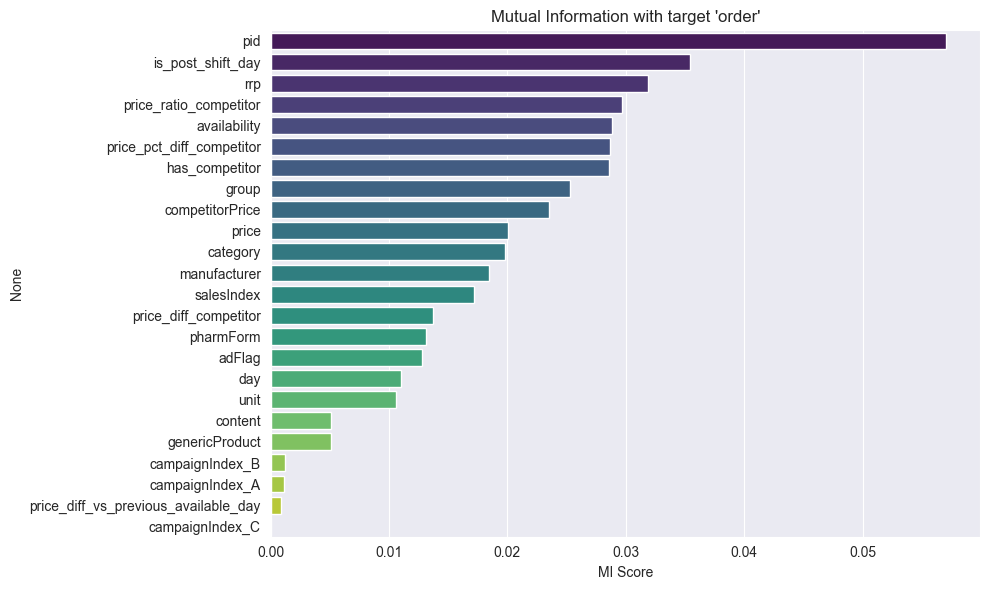

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(x=mi_series.values, y=mi_series.index, palette="viridis")
plt.title("Mutual Information with target 'order'")
plt.xlabel("MI Score")
plt.tight_layout()
plt.show()

Mutual information measures how much knowing a feature reduces uncertainty about the target — a score of 0 means the feature is statistically independent of order.

What we're looking for in the output:

Features with a clear drop-off — everything above the elbow is worth keeping

Any features scoring near 0 are candidates to drop before feeding KNN

The results shows theses: pid is too good to be true. Maybe some products are popular so it does predict it very well. This is a form of target encoding leakage. the model just memorizes which products IDs sell and does not generalize well. there for **pid is dropped**

**Strong middle group (0.02–0.04) — these are  real features:**
is_post_shift_day, rrp, price_ratio_competitor, availability, price_pct_diff_competitor, has_competitor, group, competitorPrice, price, category, manufacturer, salesIndex

**Moderate group (0.01–0.02):** price_diff_competitor, pharmForm, adFlag, day, unit — worth keeping, they contribute something meaningful.

**Not relevant / Drop zone (below 0.005):** content, genericProduct, campaignIndex_B, campaignIndex_A, price_diff_vs_previous_available_day, campaignIndex_C — near zero, they add noise and slow KNN down.

**Key insights / comparisson with Master EDA**
**On day**: EDA found a structural break at day 26 — volume jumped 59.8% and order rate dropped 14 percentage points permanently. Engineered is_post_shift_day to capture this, and it's the 2nd highest MI feature. Raw day adds little on top of that — we can drop day from our feature set.

**On price, competitorPrice, rrp**: EDA found they're correlated above 0.94 — nearly collinear. The ratio features (price_ratio_competitor, price_pct_diff_competitor) catures already the meaningful signal. We should drop raw price and keep the ratio features to avoid redundancy.

**On genericProduct**: EDA found generics have a 37.6% order rate vs 24.2% for branded — strong signal. The MI score of 0.005 seems low, but that's likely because label encoding created a misleading ordinal. keeping it at the moment.

**On campaignIndex_A/B/C**: EDA shows campaign A has 31.5% order rate vs 25.2% for no campaign — meaningful. But they scored near 0 in MI because they're sparse binary flags. Worth keeping but they're low priority at the moment.

# Train/test split & scaling

Defining feature and splitting

In [33]:
#selected features | 20 in total
selected_features = [
    # Price signals
    "price_ratio_competitor", "price_pct_diff_competitor", "price_diff_competitor",
    "competitorPrice", "rrp",
    # Product attributes
    "availability", "has_competitor", "group", "category",
    "manufacturer", "salesIndex", "pharmForm", "unit",
    "genericProduct", "adFlag", "content",
    # Campaign & timing
    "is_post_shift_day", "campaignIndex_A", "campaignIndex_B", "campaignIndex_C",
]

X = df[selected_features]
y = df["order"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")
print(f"\nClass balance in train:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nClass balance in test:")
print(y_test.value_counts(normalize=True).round(3))

Train size : (160000, 20)
Test size  : (40000, 20)

Class balance in train:
order
0    0.744
1    0.256
Name: proportion, dtype: float64

Class balance in test:
order
0    0.744
1    0.256
Name: proportion, dtype: float64


scaling

In [34]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Scaling done ✓")
print(f"Mean of first feature (should be ~0): {X_train_sc[:, 0].mean():.4f}")
print(f"Std  of first feature (should be ~1): {X_train_sc[:, 0].std():.4f}")

Scaling done ✓
Mean of first feature (should be ~0): -0.0000
Std  of first feature (should be ~1): 1.0000


# Finding Optimal K

Knn on 160k rows is slow. we'll tune it on 20 k subset, then train the final model

In [35]:
#creating a subset

X_sub, _, y_sub, _ = train_test_split(
    X_train_sc, y_train,
    train_size=20_000,
    stratify=y_train,
    random_state=42
)

print(f"Subsample size : {X_sub.shape}")
print(f"Class balance  : {pd.Series(y_sub).value_counts(normalize=True).round(3).to_dict()}")

Subsample size : (20000, 20)
Class balance  : {0: 0.744, 1: 0.256}


In [36]:
#running k tuning
k_range = range(3, 32, 2)  # odd numbers only to avoid ties: 3, 5, 7, ... 31
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for k in k_range:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        weights="distance",   # closer neighbors vote more strongly
        algorithm="ball_tree", # faster than brute force
        n_jobs=-1              # use all CPU cores
    )
    f1  = cross_val_score(knn, X_sub, y_sub, cv=cv, scoring="f1").mean()
    auc = cross_val_score(knn, X_sub, y_sub, cv=cv, scoring="roc_auc").mean()
    results.append({"k": k, "f1": f1, "auc": auc})
    print(f"k={k:>2}  F1={f1:.4f}  AUC={auc:.4f}")

results_df = pd.DataFrame(results)

k= 3  F1=0.3163  AUC=0.5934
k= 5  F1=0.3123  AUC=0.6055
k= 7  F1=0.3036  AUC=0.6112
k= 9  F1=0.2987  AUC=0.6146
k=11  F1=0.2944  AUC=0.6165
k=13  F1=0.2869  AUC=0.6182
k=15  F1=0.2804  AUC=0.6186
k=17  F1=0.2774  AUC=0.6183
k=19  F1=0.2720  AUC=0.6188
k=21  F1=0.2690  AUC=0.6195
k=23  F1=0.2646  AUC=0.6199
k=25  F1=0.2631  AUC=0.6209
k=27  F1=0.2609  AUC=0.6213
k=29  F1=0.2592  AUC=0.6215
k=31  F1=0.2587  AUC=0.6214


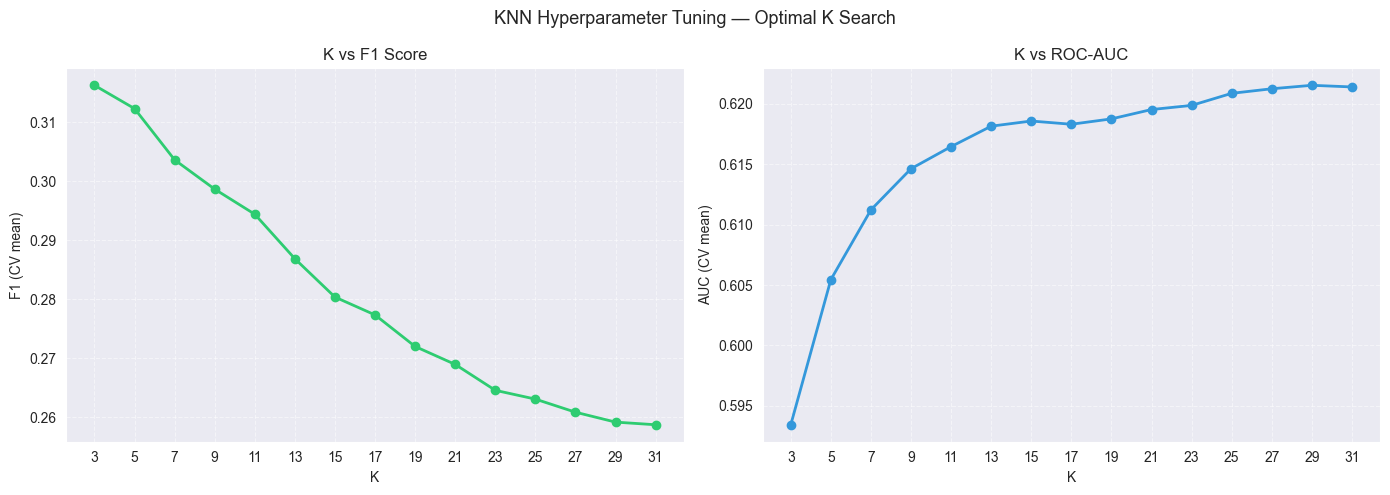


Best K by F1  : 3
Best K by AUC : 29
 k       f1      auc
 3 0.316285 0.593435
 5 0.312336 0.605451
 7 0.303646 0.611228
 9 0.298678 0.614632
11 0.294427 0.616463
13 0.286880 0.618156
15 0.280385 0.618582
17 0.277359 0.618315
19 0.272009 0.618760
21 0.268969 0.619533
23 0.264580 0.619875
25 0.263089 0.620875
27 0.260869 0.621254
29 0.259188 0.621540
31 0.258741 0.621404


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df["k"], results_df["f1"], marker="o", color="#2ecc71", linewidth=2)
axes[0].set_title("K vs F1 Score")
axes[0].set_xlabel("K")
axes[0].set_ylabel("F1 (CV mean)")
axes[0].set_xticks(list(k_range))

axes[1].plot(results_df["k"], results_df["auc"], marker="o", color="#3498db", linewidth=2)
axes[1].set_title("K vs ROC-AUC")
axes[1].set_xlabel("K")
axes[1].set_ylabel("AUC (CV mean)")
axes[1].set_xticks(list(k_range))

for ax in axes:
    ax.grid(True, linestyle="--", alpha=0.5)

plt.suptitle("KNN Hyperparameter Tuning — Optimal K Search", fontsize=13)
plt.tight_layout()
plt.show()

best_k = results_df.loc[results_df["f1"].idxmax(), "k"]
print(f"\nBest K by F1  : {best_k}")
print(f"Best K by AUC : {results_df.loc[results_df['auc'].idxmax(), 'k']}")
print(results_df.to_string(index=False))

# Train & evaluation final model for k = 7

In [39]:
#training the full training set with k=7
knn_final = KNeighborsClassifier(
    n_neighbors=7,
    weights="distance",
    algorithm="ball_tree",
    n_jobs=-1
)

knn_final.fit(X_train_sc, y_train)
print("Training done")

Training done


In [40]:
#generate predictions

y_pred       = knn_final.predict(X_test_sc)
y_pred_proba = knn_final.predict_proba(X_test_sc)[:, 1]

print("Predictions done ✓")

Predictions done ✓


In [41]:
#Evaluation of the predictions
print("=" * 45)
print("CLASSIFICATION REPORT")
print("=" * 45)
print(classification_report(y_test, y_pred, target_names=["no order", "order"]))

print(f"ROC-AUC : {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"F1      : {f1_score(y_test, y_pred):.4f}")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    no order       0.77      0.87      0.82     29766
       order       0.40      0.26      0.31     10234

    accuracy                           0.71     40000
   macro avg       0.59      0.56      0.56     40000
weighted avg       0.68      0.71      0.69     40000

ROC-AUC : 0.6350
F1      : 0.3110


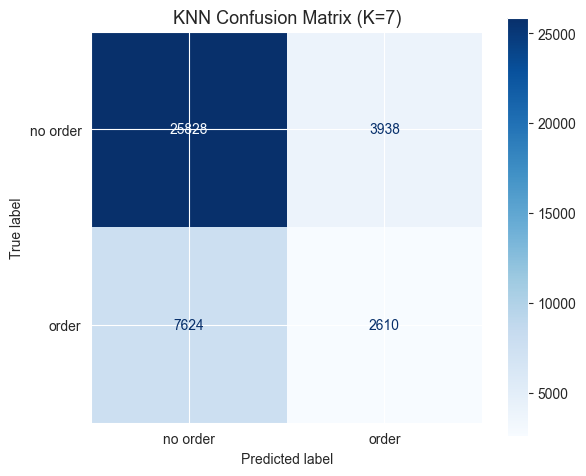

In [42]:
#confsuion matrix
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["no order", "order"],
    cmap="Blues",
    ax=ax
)

ax.set_title(f"KNN Confusion Matrix (K=7)", fontsize=13)
plt.tight_layout()
plt.show()